# COVID-19 Symptom Analysis using LASSO Logistic Regression

## Objective
Identify symptoms and symptom clusters associated with a positive COVID-19 test using LASSO logistic regression.

Models estimated:
- **1-way model:** individual symptoms
- **2-way model:** symptom pairs
- **3-way model:** symptom triplets

Outputs:
- Accuracy
- AUC
- Confusion matrix
- Top symptoms / pairs / triplets
- Heatmap of symptom interactions
- Model comparison table

Dataset: `D483.xlsx`

In [22]:
# Import libraries

import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

from patsy import dmatrices
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

plt.style.use("ggplot")

# Load dataset

df = pd.read_excel("~/Downloads/D483.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (483, 82)


,TestResult,pub,WhytestedOther,Flutest,symptoms,symptomsresp,symptomsconsresp,symptomsgastro,symptomsconsgastro,symptomsneuro,...,explasttime4=publictrans,explasttime5=airplane,explasttime6=cruise,explasttime7=barcaferest,explasttime8=grocery,explasttime9=retail,explasttime10=visit,explasttime11=gym_team,explasttime12=rlgssvc,explasttime13=hcp
0,"Yes, and I tested negative",I came into contact with someone who has the c...,NaN,"No, I have not been tested",NaN,NaN,NaN,NaN,NaN,NaN,...,Mid March to May 2020,Mid March to May 2020,Mid March to May 2020,More recently,More recently,More recently,More recently,Mid March to May 2020,More recently,August/September 2020
1,"Yes, and I tested negative",I came into contact with someone who has the c...,NaN,"Yes, and I tested negative",NaN,NaN,NaN,NaN,NaN,NaN,...,Feb. to early March 2020 or before,Feb. to early March 2020 or before,Never,More recently,More recently,More recently,More recently,Feb. to early March 2020 or before,More recently,August/September 2020
2,"Yes, and I tested positive",I came into contact with someone who has the c...,NaN,"No, I have not been tested",Fatigue (more than normal),Sore throat,No,Diarrhea,No,Headaches,...,Feb. to early March 2020 or before,Feb. to early March 2020 or before,Feb. to early March 2020 or before,More recently,More recently,August/September 2020,More recently,Feb. to early March 2020 or before,August/September 2020,More recently
3,"Yes, and I tested negative",I came into contact with someone who has the c...,NaN,"No, I have not been tested",NaN,"Runny nose,Sore throat",Yes,"Diarrhea,Stomach or abdominal pain",Yes,Headaches,...,Mid March to May 2020,Mid March to May 2020,NaN,August/September 2020,More recently,June/July 2020,August/September 2020,Mid March to May 2020,Mid March to May 2020,August/September 2020
4,"Yes, and I tested negative",I came into contact with someone who has the c...,NaN,"No, I have not been tested",NaN,Sore throat,No,Stomach or abdominal pain,No,NaN,...,Feb. to early March 2020 or before,Never,Never,More recently,More recently,More recently,More recently,June/July 2020,Feb. to early March 2020 or before,Feb. to early March 2020 or before


In [23]:
#Cleaning adn Symptom Preprocessing
# Convert test result
df["TestResult"] = df["TestResult"].map({
    "Yes, and I tested positive":1,
    "Yes, and I tested negative":0
})

# Yes/No variables
yn_vars = [
    "ACE","prevCOVID","foodpoison","flushot",
    "healthcare","essential","state","countries","children"
]

for v in yn_vars:
    if v in df.columns:
        df[v] = df[v].map({"Yes":1,"No":0})

# Other variables
df["gender"] = df["gender"].map({"Male":1,"Female":0})
df["Race"] = df["Race"].map({"White":1})
df["Ethnicity"] = df["Ethnicity"].map({"Hispanic Latino":1})

df["maskindoors"] = df["maskindoors"].astype(str).str.startswith("Yes").astype(int)
df["socialdist"] = df["socialdist"].astype(str).str.startswith("Yes").astype(int)


# --- Extract symptoms

def clean_symptom_name(x):
    return x.replace("(","").replace(")","").replace("/","").replace(" ","_").lower()

def parse_symptoms(x):
    if pd.isna(x) or str(x).startswith("None"):
        return []
    return [
    clean_symptom_name(i.strip())
    for i in str(x).split(",")
    if i.strip() != ""
]

symptom_fields = [
    "symptoms","symptomsresp","symptomsgastro",
    "symptomsneuro","symptomsinflamm"
]

all_symptoms = set()

for f in symptom_fields:
    df[f] = df[f].astype(str)
    s = df[f].apply(parse_symptoms)
    all_symptoms.update(itertools.chain(*s))

all_symptoms = sorted(
    [s for s in all_symptoms if isinstance(s, str) and s != "nan"]
)

print("Total symptoms detected:", len(all_symptoms))


# Create binary symptom variables
for s in all_symptoms:
    df[s] = df[symptom_fields].apply(
        lambda row: 1 if any(s in parse_symptoms(v) for v in row) else 0,
        axis=1
    )


# Remove rare symptoms (speed improvement)

min_count = 10
symptom_counts = df[all_symptoms].sum()
all_symptoms = symptom_counts[symptom_counts >= min_count].index.tolist()

print("Symptoms after filtering:", len(all_symptoms))


# Controls

controls = [
"Flutest","ACE","prevCOVID","foodpoison","flushot",
"healthcare","essential","state","countries","children",
"age","Race","Ethnicity","gender","maskindoors","socialdist"
]

controls = [c for c in controls if c in df.columns]

Total symptoms detected: 30
Symptoms after filtering: 28


In [24]:
#Lasso model function 
def run_lasso(formula,title):

    y,X = dmatrices(formula,df,return_type="dataframe")
    y = np.ravel(y)

    if "Intercept" in X.columns:
        X = X.drop(columns="Intercept")

    Xtrain,Xtest,ytrain,ytest = train_test_split(
        X,y,test_size=0.3,random_state=1,stratify=y
    )

    model = Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("lasso",LogisticRegression(
            penalty="l1",
            solver="saga",
            C=0.5,
            max_iter=10000
        ))
    ])

    model.fit(Xtrain,ytrain)

    pred = model.predict(Xtest)
    prob = model.predict_proba(Xtest)[:,1]

    acc = accuracy_score(ytest,pred)
    auc = roc_auc_score(ytest,prob)
    cm = confusion_matrix(ytest,pred)

    print("\n",title)
    print("Accuracy:",round(acc,3))
    print("AUC:",round(auc,3))
    print("Confusion Matrix")
    print(cm)

    coef = pd.Series(
        model.named_steps["lasso"].coef_[0],
        index=X.columns
    )

    coef = coef[coef!=0].sort_values(ascending=False)

    print("\nTop predictors")
    display(coef.head(15))

    return coef,{
        "accuracy":acc,
        "auc":auc,
        "n_predictors":len(coef)
    }

In [25]:
# run the Lasso models
formula1 = "TestResult ~ (" + " + ".join(all_symptoms) + ")"
print(df.columns)
print(formula1)
coef1,res1 = run_lasso(formula1,"1-WAY LASSO")

formula1b = formula1 + " + " + " + ".join(controls)
coef1b,res1b = run_lasso(formula1b,"1-WAY + CONTROLS")

formula2 = "TestResult ~ (" + " + ".join(all_symptoms) + ")**2"
print(formula2)
coef2,res2 = run_lasso(formula2,"2-WAY LASSO")

formula2b = formula2 + " + " + " + ".join(controls)
coef2b,res2b = run_lasso(formula2b,"2-WAY + CONTROLS")

formula3 = "TestResult ~ (" + " + ".join(all_symptoms) + ")**3"
print(formula3)
coef3,res3 = run_lasso(formula3,"3-WAY LASSO")

formula3b = formula3 + " + " + " + ".join(controls)
coef3b,res3b = run_lasso(formula3b,"3-WAY + CONTROLS")

Index(['TestResult', 'pub', 'WhytestedOther', 'Flutest', 'symptoms',
       'symptomsresp', 'symptomsconsresp', 'symptomsgastro',
       'symptomsconsgastro', 'symptomsneuro',
       ...
       'red_or_purple_rash_or_lesions_on_your_toes', 'runny_nose', 'seizures',
       'shortness_of_breath', 'slurred_speech', 'sore_throat',
       'stomach_or_abdominal_pain', 'unexplained_rashes_anywhere_else',
       'unusual_shivering_or_shaking', 'wheezing'],
      dtype='object', length=112)
TestResult ~ (any_tinglingnumbnessswelling_in_hands_or_feet + change_in_or_loss_of_appetite + chest_pain + chills + cough + diarrhea + difficulty_breathing + excessive_sweating + fatigue_more_than_normal + fever_or_feeling_feverish + headaches + joint_or_any_other_unexplained_pain + loss_of_balance + loss_of_smell + loss_of_taste + muscle_aches_not_due_to_exercise + nausea_or_vomiting + new_confusion + pinkeye_or_conjunctivitis + red_or_purple_rash_or_lesions_on_your_toes + runny_nose + shortness_of_breath +

loss_of_smell                                    1.914505
headaches                                        1.055832
chest_pain                                       0.929837
cough                                            0.543549
difficulty_breathing                             0.444771
joint_or_any_other_unexplained_pain              0.420165
unusual_shivering_or_shaking                     0.399465
wheezing                                         0.258499
loss_of_taste                                    0.095357
sore_throat                                      0.043150
change_in_or_loss_of_appetite                    0.033722
nausea_or_vomiting                               0.024208
stomach_or_abdominal_pain                       -0.196290
runny_nose                                      -0.197861
any_tinglingnumbnessswelling_in_hands_or_feet   -0.857513
dtype: float64


 1-WAY + CONTROLS
Accuracy: 0.833
AUC: 0.4
Confusion Matrix
[[5 0]
 [1 0]]

Top predictors


age   -0.049098
dtype: float64

TestResult ~ (any_tinglingnumbnessswelling_in_hands_or_feet + change_in_or_loss_of_appetite + chest_pain + chills + cough + diarrhea + difficulty_breathing + excessive_sweating + fatigue_more_than_normal + fever_or_feeling_feverish + headaches + joint_or_any_other_unexplained_pain + loss_of_balance + loss_of_smell + loss_of_taste + muscle_aches_not_due_to_exercise + nausea_or_vomiting + new_confusion + pinkeye_or_conjunctivitis + red_or_purple_rash_or_lesions_on_your_toes + runny_nose + shortness_of_breath + slurred_speech + sore_throat + stomach_or_abdominal_pain + unexplained_rashes_anywhere_else + unusual_shivering_or_shaking + wheezing)**2

 2-WAY LASSO
Accuracy: 0.827
AUC: 0.836
Confusion Matrix
[[92  8]
 [16 23]]

Top predictors


...

age   -0.047017
dtype: float64

TestResult ~ (any_tinglingnumbnessswelling_in_hands_or_feet + change_in_or_loss_of_appetite + chest_pain + chills + cough + diarrhea + difficulty_breathing + excessive_sweating + fatigue_more_than_normal + fever_or_feeling_feverish + headaches + joint_or_any_other_unexplained_pain + loss_of_balance + loss_of_smell + loss_of_taste + muscle_aches_not_due_to_exercise + nausea_or_vomiting + new_confusion + pinkeye_or_conjunctivitis + red_or_purple_rash_or_lesions_on_your_toes + runny_nose + shortness_of_breath + slurred_speech + sore_throat + stomach_or_abdominal_pain + unexplained_rashes_anywhere_else + unusual_shivering_or_shaking + wheezing)**3

 3-WAY LASSO
Accuracy: 0.835
AUC: 0.839
Confusion Matrix
[[93  7]
 [16 23]]

Top predictors


cough:loss_of_smell                                                      1.062322
difficulty_breathing:headaches:sore_throat                               0.954088
chest_pain:fever_or_feeling_feverish:muscle_aches_not_due_to_exercise    0.844601
cough:loss_of_smell:loss_of_taste                                        0.695138
cough:headaches                                                          0.609479
chest_pain:fatigue_more_than_normal:fever_or_feeling_feverish            0.598860
loss_of_smell                                                            0.490971
fatigue_more_than_normal:pinkeye_or_conjunctivitis                       0.440313
headaches:muscle_aches_not_due_to_exercise                               0.368433
headaches                                                                0.362135
fatigue_more_than_normal:fever_or_feeling_feverish:wheezing              0.309288
chest_pain:fatigue_more_than_normal:loss_of_taste                        0.306973
headaches:loss_o


 3-WAY + CONTROLS
Accuracy: 0.833
AUC: 0.4
Confusion Matrix
[[5 0]
 [1 0]]

Top predictors


age   -0.056885
dtype: float64


Top 10 Symptoms


,term,coef,abs_coef,order
41,any_tinglingnumbnessswelling_in_hands_or_feet,-0.523331,0.523331,1
6,loss_of_smell,0.490971,0.490971,1
9,headaches,0.362135,0.362135,1
36,runny_nose,-0.197475,0.197475,1
35,diarrhea,-0.158204,0.158204,1
33,fever_or_feeling_feverish,-0.112506,0.112506,1



Top 10 Symptom Pairs


,term,coef,abs_coef,order
0,cough:loss_of_smell,1.062322,1.062322,2
4,cough:headaches,0.609479,0.609479,2
7,fatigue_more_than_normal:pinkeye_or_conjunctiv...,0.440313,0.440313,2
8,headaches:muscle_aches_not_due_to_exercise,0.368433,0.368433,2
40,muscle_aches_not_due_to_exercise:stomach_or_ab...,-0.363720,0.363720,2
39,fatigue_more_than_normal:runny_nose,-0.287710,0.287710,2
37,any_tinglingnumbnessswelling_in_hands_or_feet:...,-0.217647,0.217647,2
12,headaches:loss_of_taste,0.211762,0.211762,2
13,chest_pain:fatigue_more_than_normal,0.198246,0.198246,2
15,chest_pain:muscle_aches_not_due_to_exercise,0.186348,0.186348,2



Top 10 Symptom Triplets


,term,coef,abs_coef,order
1,difficulty_breathing:headaches:sore_throat,0.954088,0.954088,3
2,chest_pain:fever_or_feeling_feverish:muscle_ac...,0.844601,0.844601,3
3,cough:loss_of_smell:loss_of_taste,0.695138,0.695138,3
5,chest_pain:fatigue_more_than_normal:fever_or_f...,0.598860,0.598860,3
10,fatigue_more_than_normal:fever_or_feeling_feve...,0.309288,0.309288,3
11,chest_pain:fatigue_more_than_normal:loss_of_taste,0.306973,0.306973,3
38,fever_or_feeling_feverish:muscle_aches_not_due...,-0.275991,0.275991,3
14,cough:fever_or_feeling_feverish:loss_of_taste,0.198223,0.198223,3
16,cough:fever_or_feeling_feverish:runny_nose,0.133082,0.133082,3
34,cough:muscle_aches_not_due_to_exercise:stomach...,-0.124600,0.124600,3


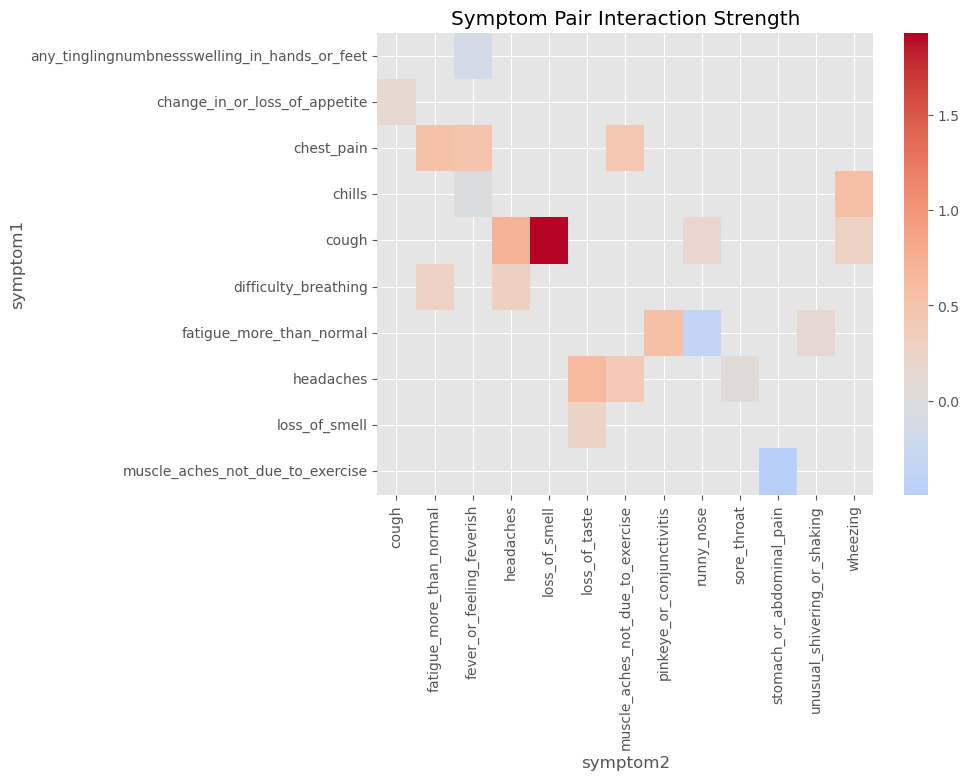

,Model,Accuracy,AUC
4,3-way symptoms,0.834532,0.839487
2,2-way symptoms,0.827338,0.835513
0,1-way symptoms,0.791367,0.769359
1,1-way + controls,0.833333,0.400000
3,2-way + controls,0.833333,0.400000
5,3-way + controls,0.833333,0.400000


In [26]:
# Top Predictors, Heatmap & Model Comparison
# --- Top symptoms / pairs / triplets

df_coef = pd.DataFrame({
    "term":coef3.index,
    "coef":coef3.values
})

df_coef["abs_coef"] = df_coef["coef"].abs()
df_coef["order"] = df_coef["term"].apply(lambda x: x.count(":")+1)

print("\nTop 10 Symptoms")
display(df_coef[df_coef["order"]==1].sort_values("abs_coef",ascending=False).head(10))

print("\nTop 10 Symptom Pairs")
display(df_coef[df_coef["order"]==2].sort_values("abs_coef",ascending=False).head(10))

print("\nTop 10 Symptom Triplets")
display(df_coef[df_coef["order"]==3].sort_values("abs_coef",ascending=False).head(10))


# --- Heatmap of symptom pairs

pairs = coef2[[i.count(":")==1 for i in coef2.index]]

pair_df = pd.DataFrame({"pair":pairs.index,"coef":pairs.values})
pair_df[["symptom1","symptom2"]] = pair_df["pair"].str.split(":",expand=True)

matrix = pair_df.pivot(index="symptom1",columns="symptom2",values="coef")

plt.figure(figsize=(8,6))
sns.heatmap(matrix,cmap="coolwarm",center=0)
plt.title("Symptom Pair Interaction Strength")
plt.show()


# --- Model comparison

comparison = pd.DataFrame({

"Model":[
"1-way symptoms",
"1-way + controls",
"2-way symptoms",
"2-way + controls",
"3-way symptoms",
"3-way + controls"
],

"Accuracy":[
res1["accuracy"],res1b["accuracy"],
res2["accuracy"],res2b["accuracy"],
res3["accuracy"],res3b["accuracy"]
],

"AUC":[
res1["auc"],res1b["auc"],
res2["auc"],res2b["auc"],
res3["auc"],res3b["auc"]
]

})

comparison.sort_values("AUC",ascending=False)

## Bonus: Regression Including Other Variables

In addition to symptoms, we include demographic and behavioral variables:

- Age
- Gender
- Race
- Ethnicity
- Mask use
- Social distancing
- Prior COVID infection
- Healthcare worker status
- Other exposure variables

This allows us to test whether symptoms remain predictive
after controlling for these additional factors.


In [27]:
# Regression including symptoms + other variables

formula_bonus = (
    "TestResult ~ ("
    + " + ".join(all_symptoms)
    + ") + "
    + " + ".join(controls)
)

coef_bonus, res_bonus = run_lasso(
    formula_bonus,
    "BONUS MODEL: Symptoms + Demographic/Behavioral Variables"
)


 BONUS MODEL: Symptoms + Demographic/Behavioral Variables
Accuracy: 0.833
AUC: 0.4
Confusion Matrix
[[5 0]
 [1 0]]

Top predictors


age   -0.044357
dtype: float64

### Bonus: Regression Including Demographic and Behavioral Variables

When demographic and behavioral variables were added to the model, LASSO retained only **age** as an additional predictor. Other variables such as **gender**, **race**, **mask use**, and **prior COVID infection** were shrunk to zero by the L1 regularization.

This indicates that these variables did not provide additional predictive power beyond the symptom variables. The results suggest that **symptoms remain the primary predictors of COVID-19 test outcomes**, while demographic and behavioral characteristics contribute relatively little additional information once symptoms are included in the model.